# Kamen Rider Image Convolutions with MPI and CUDA

Parallel image convolution using **MPI** and **CUDA**.

This notebook executes:

- MPI parallel processing
- CUDA GPU acceleration
- OpenCV image processing
- `parallel_image` executable

Project: **Schryzon/mpyCUDA**  
Course: **Parallel Processing A**

By: I Nyoman Widiyasa Jayananda (F1D02410053)

[![GitHub Repository](https://img.shields.io/badge/GitHub-mpyCUDA-black?style=for-the-badge&logo=github)](https://github.com/Schryzon/mpyCUDA)
[![Henshin Ready](https://img.shields.io/badge/Henshin-Ready-00BA00?style=for-the-badge&logo=nvidia&logoColor=white)](https://github.com/Schryzon/mpyCUDA)


> ### 🛑 HENSHIN IMPOSSIBLE: ENABLE YOUR GPU!
> **This project REQUIRES a CUDA-capable GPU (NVIDIA T4 or better).**
> If you run this on a standard CPU runtime, the GPU kernels will fail silently and result in unchanged images.
>
> **How to fix:**
> 1. Go to **Runtime** → **Change runtime type**
> 2. Select **T4 GPU** (or better)
> 3. Click **Save**
>
> *Obaachan ga itte ita... "You cannot walk the path of heaven if your engine is not even turned on."*

## Mount Google Drive

In [1]:
import os
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

DRIVE_PATH = '/content/drive/MyDrive/Jay-IF24-mpyCUDA'
REPO_URL   = 'https://github.com/Schryzon/mpyCUDA.git'

if not os.path.exists(DRIVE_PATH):
    print('Repository not found in Drive. Cloning now...')
    !git clone "{REPO_URL}" "{DRIVE_PATH}"
    print('Clone complete!')
else:
    print('Repository already exists in Drive. Pulling latest changes...')
    !git -C "{DRIVE_PATH}" pull

# Create a fast symlink in /content so all relative paths work correctly
WORK_DIR = '/content/mpyCUDA'
if not os.path.exists(WORK_DIR):
    !ln -s "{DRIVE_PATH}" "{WORK_DIR}"

print(f'Working directory: {WORK_DIR}')

%cd mpyCUDA/Kamen-Rider-Image-Convolution

Mounted at /content/drive
Repository already exists in Drive. Pulling latest changes...
remote: Enumerating objects: 11, done.
remote: Counting objects: 100% (11/11), done.
remote: Compressing objects: 100% (5/5), done.
remote: Total 8 (delta 5), reused 6 (delta 3), pack-reused 0 (from 0)
Unpacking objects: 100% (8/8), 2.70 MiB | 2.47 MiB/s, done.
From https://github.com/Schryzon/mpyCUDA
   8037f00..5a280a6  master     -> origin/master
Updating 8037f00..5a280a6
Fast-forward
 Kamen-Rider-Image-Convolution/colab_notebook.ipynb | 1568 ++++++++++----------
 1 file changed, 811 insertions(+), 757 deletions(-)
Working directory: /content/mpyCUDA
/content/drive/MyDrive/Jay-IF24-mpyCUDA/Kamen-Rider-Image-Convolution


## Install Packages and Libraries

In [2]:
%%bash
set -e
export DEBIAN_FRONTEND=noninteractive

apt-get update -qq
apt-get install -y -qq build-essential openmpi-bin openmpi-common libopenmpi-dev libopencv-dev cmake tree >/dev/null
echo "apt-get done."

apt-get done.


W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)


In [3]:
!echo "--- MPI ---" && mpirun --version
!echo "--- nvcc ---" && nvcc --version
!echo "--- OpenCV ---" && pkg-config --modversion opencv4

--- MPI ---
mpirun (Open MPI) 4.1.2

Report bugs to http://www.open-mpi.org/community/help/
--- nvcc ---
nvcc: NVIDIA (R) Cuda compiler driver
Copyright (c) 2005-2025 NVIDIA Corporation
Built on Fri_Feb_21_20:23:50_PST_2025
Cuda compilation tools, release 12.8, V12.8.93
Build cuda_12.8.r12.8/compiler.35583870_0
--- OpenCV ---
4.5.4


In [4]:
!tree -L 3

.
├── colab_notebook.ipynb
├── colab_run.ipynb
├── convert_linux.py
├── hosts.txt
├── images
│   ├── decade.jpg
│   ├── kuuga.jpg
│   ├── output
│   │   ├── blur
│   │   ├── edge
│   │   ├── emboss
│   │   ├── sharpen
│   │   └── sobel
│   ├── ryuki.jpg
│   └── w_lunatrigger.png
├── notebook_image_linux.ipynb
├── notebook_image_windows.ipynb
├── notebook_linux.ipynb
├── notebook_windows.ipynb
├── README.md
└── scripts
    ├── Makefile
    ├── parallel_conv
    ├── parallel_conv.cu
    ├── parallel_image
    ├── parallel_image.cu
    └── sequential_conv.cpp

8 directories, 19 files


## parallel_image.cu CUDA file

In [16]:
from pathlib import Path
from IPython.display import HTML, display
from pygments import highlight
from pygments.lexers import CppLexer
from pygments.formatters import HtmlFormatter

path = Path("./scripts/parallel_image.cu")
text = path.read_text(encoding="utf-8", errors="replace")
n_lines = text.count("\n") + 1

# Pygments HTML formatter with a dark background
formatter = HtmlFormatter(style='colorful', full=False, linenos=False, cssclass="highlight")
highlighted_code = highlight(text, CppLexer(), formatter)

# Inject custom CSS for the dark background if needed (though 'colorful' style might handle it)
# You can customize the style further here or by importing a specific Pygments style

display(HTML(f"""
<details open>
  <summary><b>{path.name}</b> ({n_lines} lines)</summary>
  <style>
    .highlight pre {{ background-color: #0b1021 !important; color: #f8f8f2 !important; padding: 12px; border-radius: 8px; max-height: 650px; overflow: auto; white-space: pre; }}
    .highlight .k {{ color: #E6DB74; }} /* keywords */
    .highlight .kd {{ color: #66D9EF; }} /* declaration keywords */
    .highlight .kp {{ color: #FD971F; }} /* preprocessor keywords */
    .highlight .nc {{ color: #A6E22E; }} /* class names */
    .highlight .nf {{ color: #A6E22E; }} /* function names */
    .highlight .s {{ color: #E6DB74; }} /* strings */
    .highlight .c {{ color: #75715E; font-style: italic; }} /* comments */
    .highlight .mi {{ color: #AE81FF; }} /* integer literals */
    .highlight .mf {{ color: #AE81FF; }} /* float literals */
    .highlight .o {{ color: #F92672; }} /* operators */
    .highlight .p {{ color: #F8F8F2; }} /* punctuation */
    .highlight .nv {{ color: #F8F8F2; }} /* variable names */
    .highlight .nb {{ color: #F8F8F2; }} /* builtin */
  </style>
  <div class="highlight">
    <pre>{highlighted_code}</pre>
  </div>
</details>
"""))

## Compile CUDA Binaries

In [6]:
SCRIPTS_DIR = f'{WORK_DIR}/Kamen-Rider-Image-Convolution/scripts'

print('Compiling parallel_conv and parallel_image...')
result = !make -C "{SCRIPTS_DIR}" all 2>&1
print('\n'.join(result))

# Verify binaries exist
for binary in ['parallel_conv', 'parallel_image']:
    path = f'{SCRIPTS_DIR}/{binary}'
    if os.path.exists(path):
        print(f'✅ {binary} compiled successfully')
    else:
        print(f'❌ {binary} FAILED to compile — check output above')

Compiling parallel_conv and parallel_image...
make: Entering directory '/content/drive/MyDrive/Jay-IF24-mpyCUDA/Kamen-Rider-Image-Convolution/scripts'
make: Nothing to be done for 'all'.
make: Leaving directory '/content/drive/MyDrive/Jay-IF24-mpyCUDA/Kamen-Rider-Image-Convolution/scripts'
✅ parallel_conv compiled successfully
✅ parallel_image compiled successfully


In [7]:
# Copy the compiled binary to local /content
!cp "{SCRIPTS_DIR}/parallel_image" /content/parallel_image

# Grant execution permissions
!chmod +x /content/parallel_image

print("Binary moved and permissions granted.")

Binary moved and permissions granted.


In [8]:
!ls

colab_notebook.ipynb  images			    notebook_windows.ipynb
colab_run.ipynb       notebook_image_linux.ipynb    README.md
convert_linux.py      notebook_image_windows.ipynb  scripts
hosts.txt	      notebook_linux.ipynb


In [9]:
import os

# Define the directory structure needed for the convolution outputs
filters = ['blur', 'edge', 'emboss', 'sharpen', 'sobel']
images  = ['decade', 'kuuga', 'ryuki', 'w_lunatrigger']

print("Henshin! Creating output directory structure...")

for f in filters:
    for img in images:
        path = f'images/output/{f}/{img}'
        os.makedirs(path, exist_ok=True)

print("✅ Directory structure ready for processing.")

Henshin! Creating output directory structure...
✅ Directory structure ready for processing.


## Initiate Parallel Processing

In [10]:
from pathlib import Path
import subprocess, re
import numpy as np
import matplotlib.pyplot as plt

procs = [2, 4, 6] # Add more if u want

images = [
    "decade.jpg",
    "kuuga.jpg",
    "w_lunatrigger.png",
    "ryuki.jpg"
]

input_prefix = "./images/"
output_prefix = "./images/output"

MPIEXEC = "mpirun"
PARALLEL_EXE = "/content/parallel_image"

ops = ["blur", "edge", "sobel", "sharpen", "emboss"]

time_re = re.compile(r"Time taken:\s*([0-9.]+)")

In [11]:
def run_op(op: str):
    times = []

    for image in images:
        stem = Path(image).stem
        in_img = str(Path(input_prefix) / image)

        out_dir = Path(output_prefix) / op / stem
        out_dir.mkdir(parents=True, exist_ok=True)

        for p in procs:

            out_img = str(out_dir / f"{stem}_{p}.jpg")

            cmd = [
                MPIEXEC,
                "--oversubscribe",
                "--allow-run-as-root",
                "-np", str(p),
                PARALLEL_EXE,
                in_img,
                out_img,
                op,
            ]

            print("Running:", " ".join(cmd))

            result = subprocess.run(
                cmd,
                capture_output=True,
                text=True
            )

            # This will print CUDA/MPI errors in the output cell
            if result.stderr:
                print(f"DEBUG Error for {op}: {result.stderr}")

            # This prints the timing or other stdout
            if result.stdout:
                print(result.stdout)

            combined = (
                (result.stdout or "")
                + "\n"
                + (result.stderr or "")
            )

            m = time_re.search(combined)

            if not m:
                raise RuntimeError(
                    f"Timing parse failed:\n{combined}"
                )

            t = float(m.group(1))
            times.append(t)

    return times

In [12]:
times_by_op = {}

for op in ops:
    times_by_op[op] = run_op(op)

times_by_op

Running: mpirun --oversubscribe --allow-run-as-root -np 2 /content/parallel_image images/decade.jpg images/output/blur/decade/decade_2.jpg blur
Rank 0 started
Rank 1 started
Image Loaded: 985x1613 channels: 3 Mode: blur Strength: 5 with 2 ranks.
Using GUIDED scheduling for load balancing.
Rank 1 processing rows 0 to 805
Rank 1 processing rows 806 to 1208
Rank 1 processing rows 1209 to 1410
Rank 1 processing rows 1411 to 1511
Rank 1 processing rows 1512 to 1561
Rank 1 processing rows 1562 to 1586
Rank 1 processing rows 1587 to 1602
Rank 1 processing rows 1603 to 1612
Rank 1 finished
Time taken: 0.429564
Rank 0 finished

Running: mpirun --oversubscribe --allow-run-as-root -np 4 /content/parallel_image images/decade.jpg images/output/blur/decade/decade_4.jpg blur
Rank 2 started
Rank 0 started
Rank 3 started
Rank 1 started
Image Loaded: 985x1613 channels: 3 Mode: blur Strength: 5 with 4 ranks.
Using GUIDED scheduling for load balancing.
Rank 2 processing rows 0 to 267
Rank 1 processing row

{'blur': [0.429564,
  1.113516,
  0.97024,
  0.192943,
  0.630835,
  0.94637,
  0.207193,
  0.869757,
  1.425246,
  0.286017,
  0.699249,
  0.842034],
 'edge': [0.211683,
  0.700255,
  1.532268,
  0.331573,
  0.709517,
  0.811068,
  0.216022,
  0.67533,
  1.360863,
  0.405801,
  0.651309,
  0.916403],
 'sobel': [0.208705,
  0.672404,
  0.903784,
  0.351515,
  0.805965,
  0.948112,
  0.279884,
  0.67474,
  1.167582,
  0.198591,
  0.876932,
  0.979003],
 'sharpen': [0.249617,
  0.681091,
  1.028835,
  0.215535,
  0.874259,
  1.478257,
  0.210241,
  0.804457,
  0.966161,
  0.209853,
  0.624765,
  1.205109],
 'emboss': [0.354736,
  0.741922,
  0.902329,
  0.26545,
  0.698529,
  1.193789,
  0.386767,
  0.703137,
  0.853088,
  0.197278,
  0.688588,
  0.791621]}

## Show Execution Time & Speedup Graphs

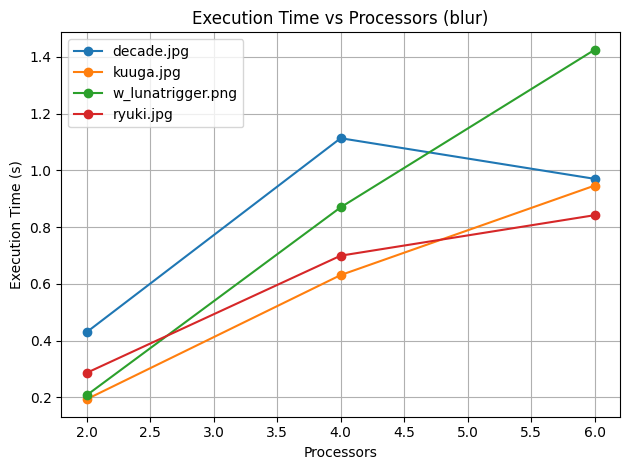

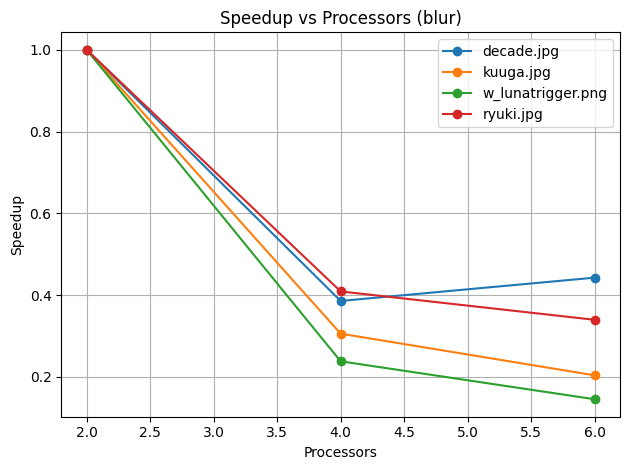

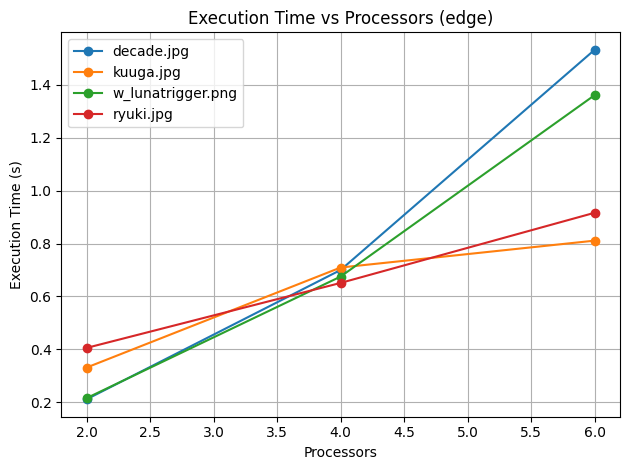

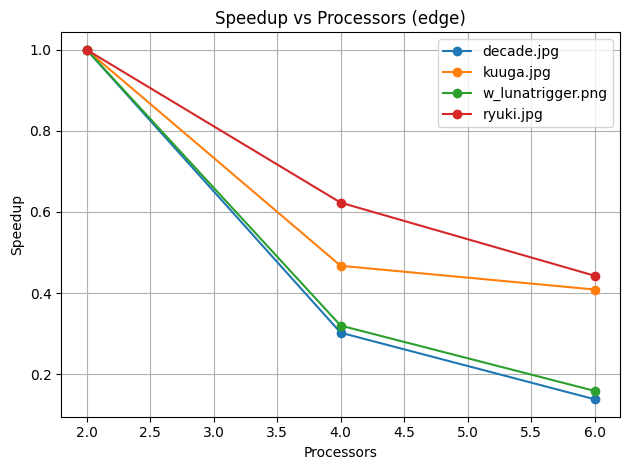

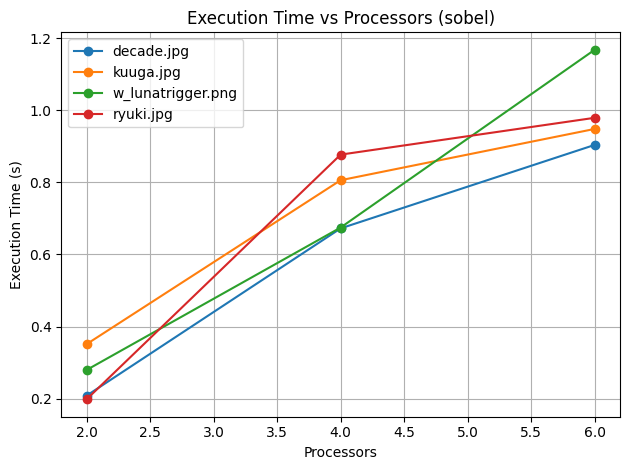

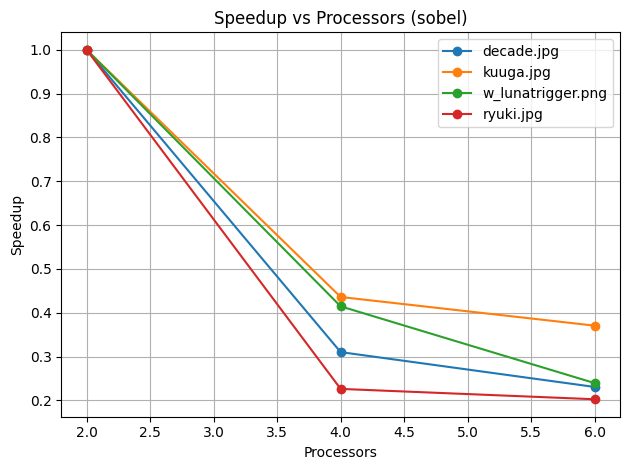

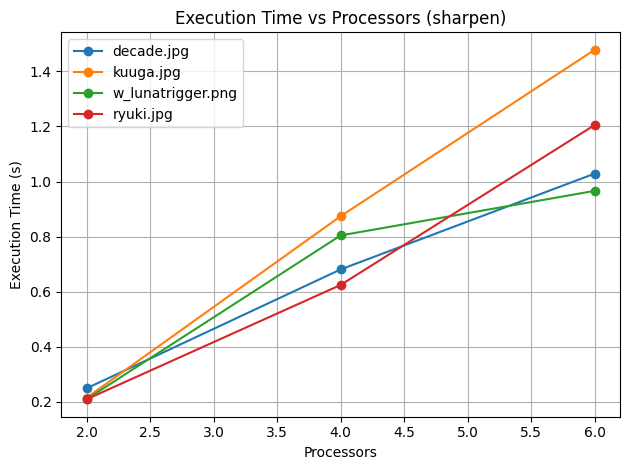

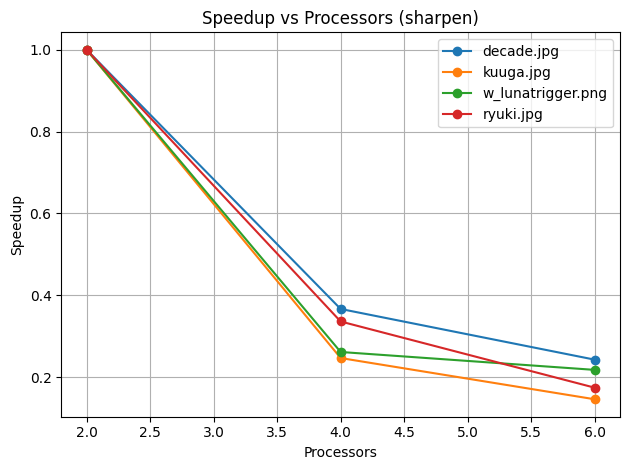

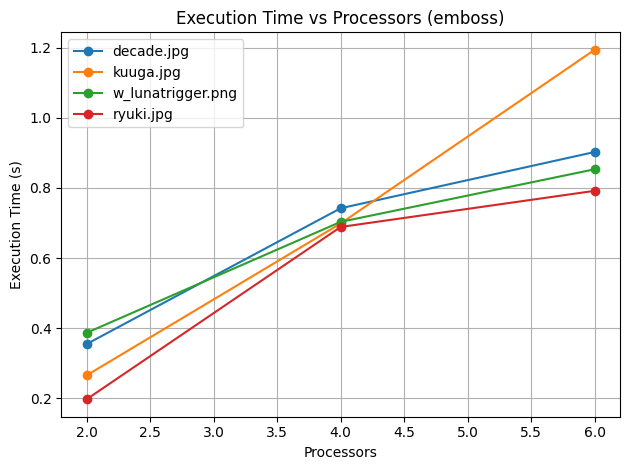

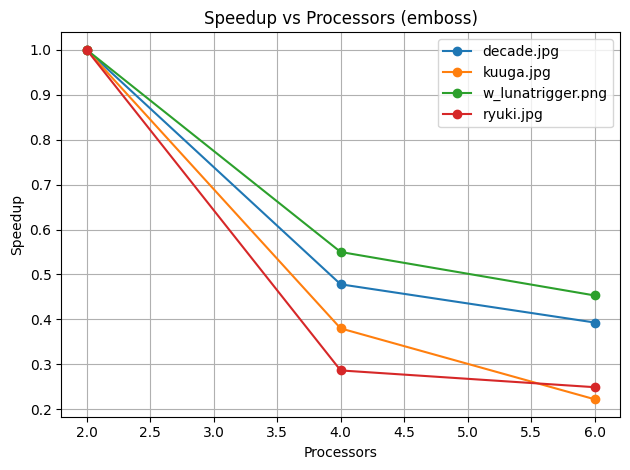

In [13]:
n_images = len(images)
n_procs = len(procs)

for op in ops:

    times_arr = np.array(
        times_by_op[op],
        dtype=float
    ).reshape(n_images, n_procs)

    speedup_arr = times_arr[:, [0]] / times_arr

    # Execution Time Plot
    plt.figure()

    for i, img in enumerate(images):
        plt.plot(
            procs,
            times_arr[i],
            marker="o",
            label=img
        )

    plt.xlabel("Processors")
    plt.ylabel("Execution Time (s)")
    plt.title(f"Execution Time vs Processors ({op})")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # Speedup Plot
    plt.figure()

    for i, img in enumerate(images):
        plt.plot(
            procs,
            speedup_arr[i],
            marker="o",
            label=img
        )

    plt.xlabel("Processors")
    plt.ylabel("Speedup")
    plt.title(f"Speedup vs Processors ({op})")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

## Compare Convoluted Images with Original

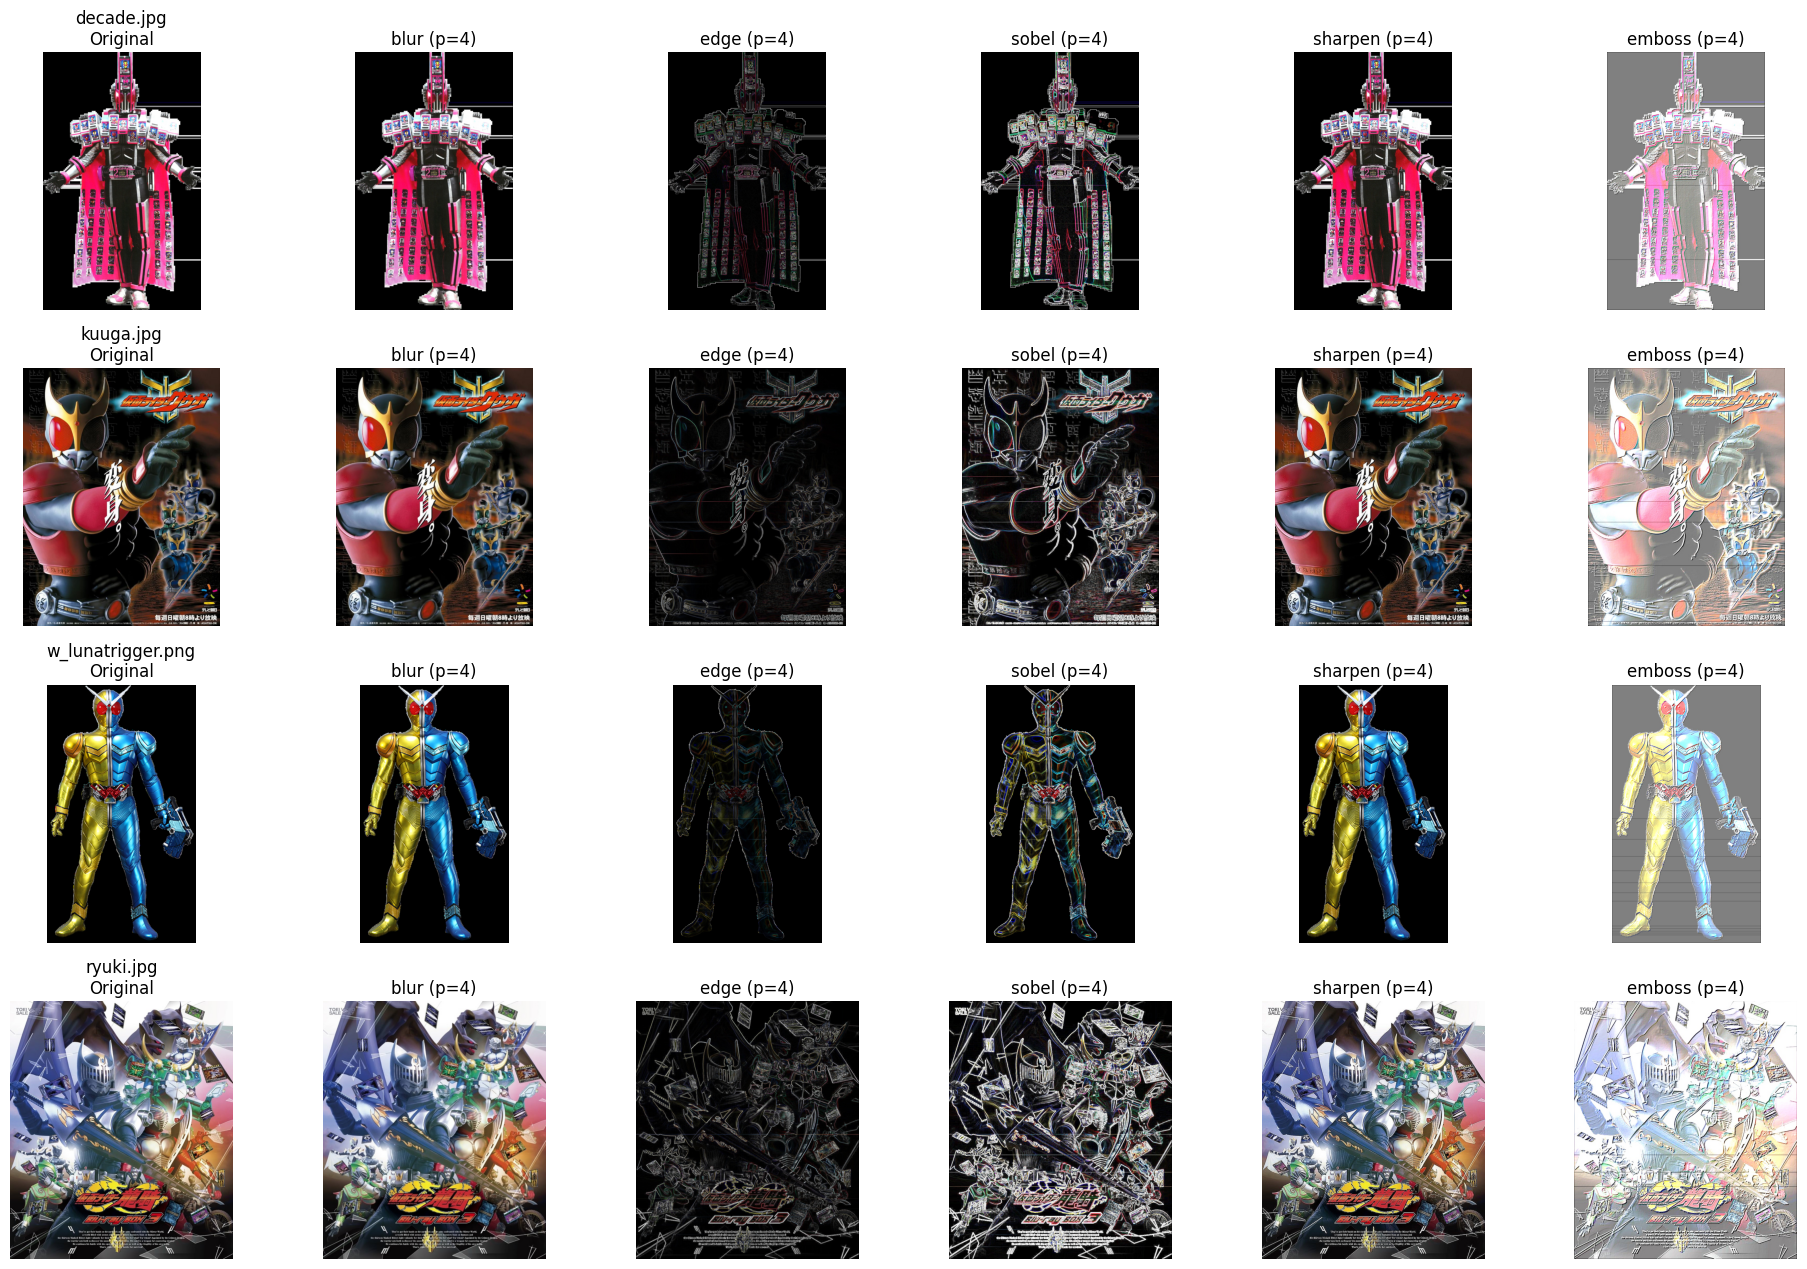

In [14]:
from pathlib import Path
import os
import numpy as np
import matplotlib.pyplot as plt

P = 4

cwd = Path(os.getcwd())

def _read_img(path: Path):
    img = plt.imread(str(path))

    if (
        isinstance(img, np.ndarray)
        and img.ndim == 3
        and img.shape[2] == 4
    ):
        img = img[:, :, :3]

    return img

n_rows = len(images)
n_cols = 1 + len(ops)

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(3.2 * n_cols, 3.2 * n_rows),
    squeeze=False
)

for r, image in enumerate(images):

    stem = Path(image).stem
    in_path = (cwd / input_prefix / image).resolve()

    ax = axes[r, 0]

    if in_path.exists():
        ax.imshow(_read_img(in_path))
        ax.set_title(f"{image}\nOriginal")
    else:
        ax.text(0.5, 0.5, "Missing")

    ax.axis("off")

    for c, op in enumerate(ops, start=1):

        out_path = (
            cwd /
            output_prefix /
            op /
            stem /
            f"{stem}_{P}.jpg"
        ).resolve()

        ax = axes[r, c]

        if out_path.exists():
            ax.imshow(_read_img(out_path))
            ax.set_title(f"{op} (p={P})")
        else:
            ax.text(0.5, 0.5, "Missing")

        ax.axis("off")

plt.tight_layout()
plt.show()